# Assignment 2 — Polynomial & Gaussian Basis Regression
**AIMS Ghana — Machine Learning Course, 2025**
**Author:** Mawulikplimi Roland Hounkpe | `rhounkpe`

---

## Overview

In this assignment we explore **flexible basis function regression**:

$$\hat{f}(x; \theta) = \Phi(x)\theta$$

where $\Phi$ is a design matrix built from basis functions (polynomial, Gaussian, or radial).
Despite non-linearity in $x$, the model is **linear in $\theta$**, so the Normal Equation applies.

### Topics
1. Polynomial regression
2. Train / validation split — bias-variance trade-off
3. K-Fold Cross-Validation
4. Ridge Regularisation (L2)
5. Gaussian basis functions
6. Radial Basis Functions (RBF)
7. Logistic regression (gradient descent)


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')


## 1. Load and Visualise the Data

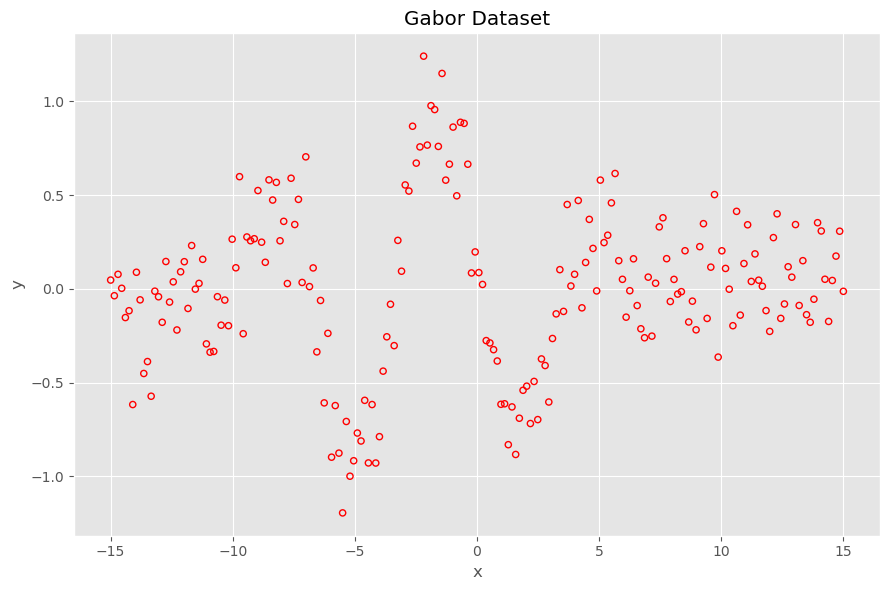

Dataset: 200 samples  |  x ∈ [-15.00, 15.00]


In [3]:
data = np.loadtxt('data/gabor_data.out')
xi = data[:, 0]
yi = data[:, 1]

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=20, facecolors='none', edgecolors='red', linewidths=1)
plt.xlabel('x'); plt.ylabel('y'); plt.title('Gabor Dataset')
plt.tight_layout(); plt.show()
print(f'Dataset: {len(xi)} samples  |  x ∈ [{xi.min():.2f}, {xi.max():.2f}]')


## 2. Helper Functions

These three functions are used throughout all questions.


In [4]:
def design_matrix(x, deg):
    """
    Polynomial design matrix of degree `deg`.
    Columns: [x^0, x^1, ..., x^deg]  (increasing powers).

    Note: the original code used descending powers [x^deg, ..., x^0].
    We use increasing powers here for clarity — fit() works the same either way.
    """
    return np.column_stack([x ** k for k in range(deg + 1)])

def fit(X, y):
    """Solve the Normal Equation: theta = (X^T X)^{-1} X^T y"""
    return np.linalg.solve(X.T.dot(X), X.T.dot(y))

def predict(X, coefs):
    """Model prediction: y_hat = X @ theta"""
    return X.dot(coefs)

def mse(y_true, y_pred):
    """Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)


## 3. Question 1 — Polynomial Regression (degree 20)

We build the design matrix $\Phi \in \mathbb{R}^{m \times (d+1)}$ with columns $[1, x, x^2, \ldots, x^d]$
and solve the Normal Equation.


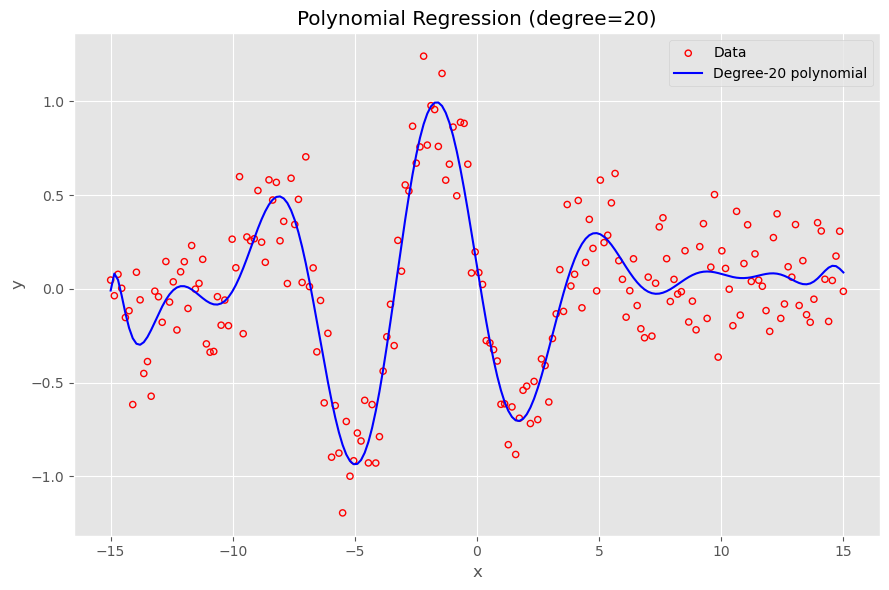

In [6]:
deg   = 20
x_plt = np.linspace(xi.min(), xi.max(), 200)

X     = design_matrix(xi, deg)
coefs = fit(X, yi)
model = predict(design_matrix(x_plt, deg), coefs)

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=20, facecolors='none', edgecolors='red', linewidths=1, label='Data')
plt.plot(x_plt, model, 'b-', linewidth=1.5, label=f'Degree-{deg} polynomial')
plt.title(f'Polynomial Regression (degree={deg})')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.tight_layout(); plt.show()


## 4. Question 2 — Comparing Polynomial Degrees

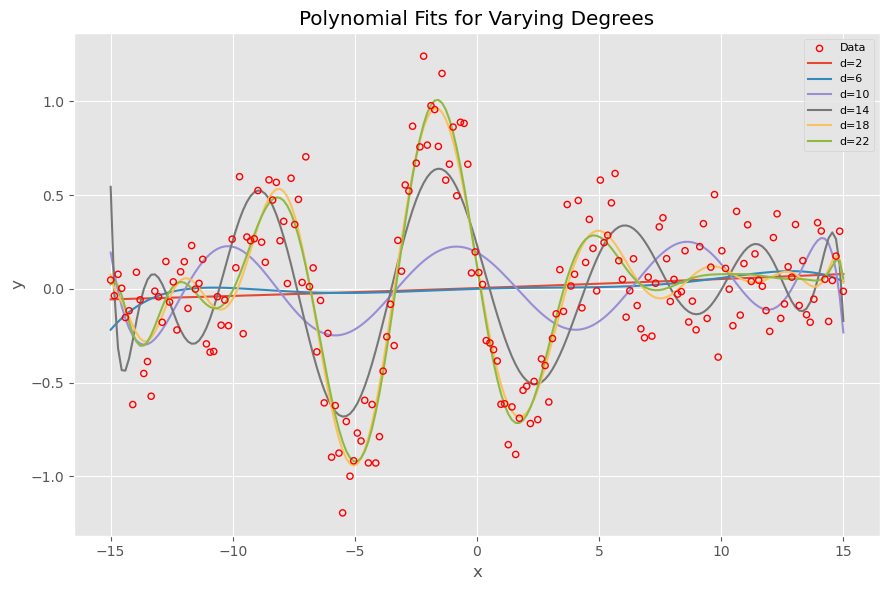

In [8]:
list_of_poly_deg = np.arange(2, 24, 4)
mse_train_lst    = []

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=20, facecolors='none', edgecolors='red', linewidths=1, label='Data', zorder=5)

for n in list_of_poly_deg:
    X_n    = design_matrix(xi, n)
    coefs_n = fit(X_n, yi)
    y_plot  = predict(design_matrix(x_plt, n), coefs_n)
    mse_train_lst.append(mse(yi, predict(X_n, coefs_n)))
    plt.plot(x_plt, y_plot, linewidth=1.5, label=f'd={n}')

plt.legend(fontsize=8); plt.title('Polynomial Fits for Varying Degrees')
plt.xlabel('x'); plt.ylabel('y'); plt.tight_layout(); plt.show()


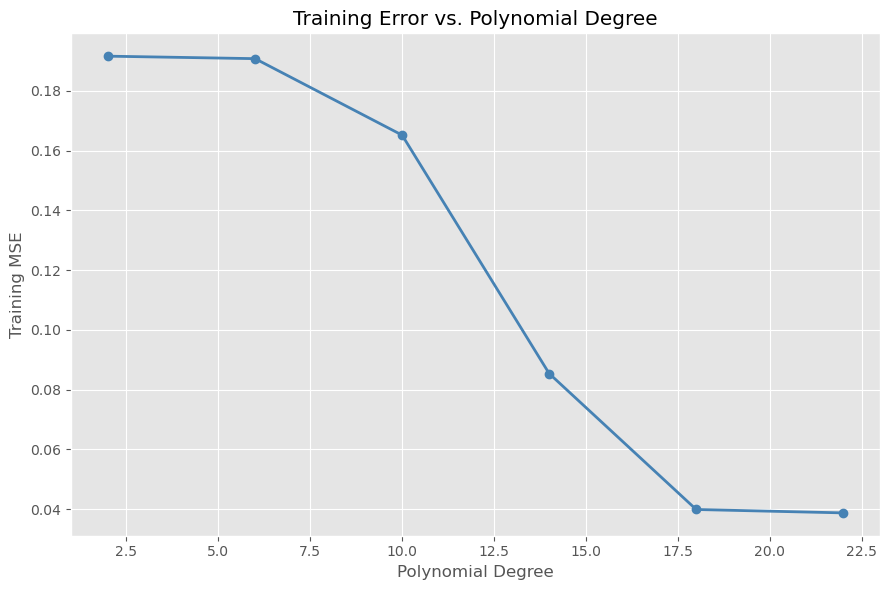

In [9]:
plt.figure(figsize=(9, 6))
plt.plot(list_of_poly_deg, mse_train_lst, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Polynomial Degree'); plt.ylabel('Training MSE')
plt.title('Training Error vs. Polynomial Degree')
plt.tight_layout(); plt.show()


**Observation:** Training MSE decreases as degree increases — a higher-degree polynomial has more parameters and fits the training data more closely. But this does **not** mean it generalises better to new data.


## 5. Question 3 — Train / Validation Split

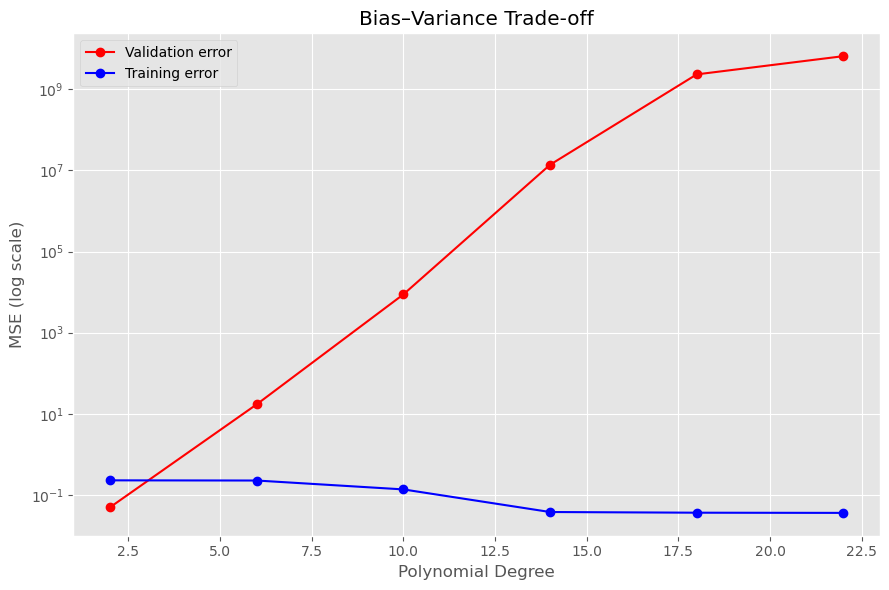

In [11]:
# 80/20 split
n_train = int(0.8 * len(xi))
x_train, y_train = xi[:n_train], yi[:n_train]
x_test,  y_test  = xi[n_train:], yi[n_train:]

mse_test_lst   = []
mse_train_lst2 = []

for n in list_of_poly_deg:
    X_tr  = design_matrix(x_train, n)
    X_te  = design_matrix(x_test,  n)
    c     = fit(X_tr, y_train)
    mse_test_lst.append(  mse(y_test,  predict(X_te, c)))
    mse_train_lst2.append(mse(y_train, predict(X_tr, c)))

plt.figure(figsize=(9, 6))
plt.semilogy(list_of_poly_deg, mse_test_lst,   'o-r',  label='Validation error')
plt.semilogy(list_of_poly_deg, mse_train_lst2, 'bo-',  label='Training error')
plt.xlabel('Polynomial Degree'); plt.ylabel('MSE (log scale)')
plt.title('Bias–Variance Trade-off')
plt.legend(); plt.tight_layout(); plt.show()


**Conclusion:** The validation error is U-shaped. The optimal degree is around **d = 3** where training and validation errors are closest and both remain low.

- Low degree → **underfitting** (high bias)
- High degree → **overfitting** (high variance)


## 6. Question 4 — K-Fold Cross-Validation

In [12]:
def k_fold_cv(x, y, deg, k=5):
    """
    Run k-fold cross-validation for a polynomial model of given degree.

    Parameters
    ----------
    x   : input array (m,)
    y   : target array (m,)
    deg : polynomial degree
    k   : number of folds

    Returns
    -------
    mse_val_scores, mse_train_scores : lists of length k
    """
    n       = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    fold_sz = n // k
    mse_val_scores   = []
    mse_train_scores = []

    for fold in range(k):
        start     = fold * fold_sz
        end       = start + fold_sz
        val_idx   = indices[start:end]
        train_idx = np.r_[indices[:start], indices[end:]]

        xi_train, yi_train = x[train_idx], y[train_idx]
        xi_val,   yi_val   = x[val_idx],   y[val_idx]

        X_train = design_matrix(xi_train, deg)
        X_val   = design_matrix(xi_val,   deg)
        coefs   = fit(X_train, yi_train)

        mse_val_scores.append(  mse(yi_val,   predict(X_val,   coefs)))
        mse_train_scores.append(mse(yi_train, predict(X_train, coefs)))

    return mse_val_scores, mse_train_scores

scores_val, scores_train = k_fold_cv(xi, yi, 20, k=5)
print('MSE per fold (validation):', [round(s,4) for s in scores_val])
print('Average validation MSE   :', np.mean(scores_val))
print('Average training MSE     :', np.mean(scores_train))


MSE per fold (validation): [np.float64(0.0497), np.float64(0.074), np.float64(0.0561), np.float64(0.0508), np.float64(0.0572)]
Average validation MSE   : 0.05759296192078891
Average training MSE     : 0.03764677744968709


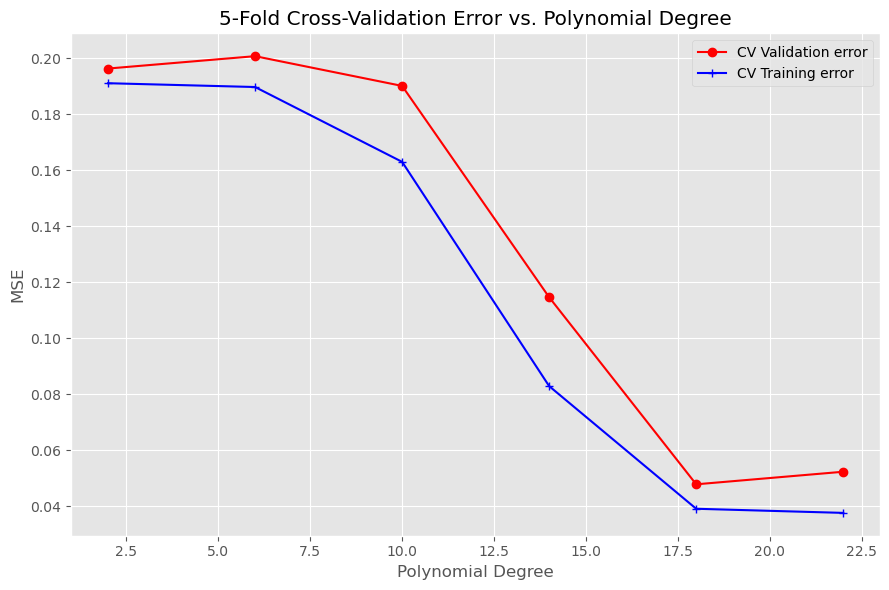

In [15]:
mse_val_lst   = []
mse_train_lst = []
for n in list_of_poly_deg:
    sv, st = k_fold_cv(xi, yi, n, k=5)
    mse_val_lst.append(  np.mean(sv))
    mse_train_lst.append(np.mean(st))

plt.figure(figsize=(9, 6))
plt.plot(list_of_poly_deg, mse_val_lst,   'o-r',  label='CV Validation error')
plt.plot(list_of_poly_deg, mse_train_lst, 'b+-',  label='CV Training error')
plt.xlabel('Polynomial Degree'); plt.ylabel('MSE')
plt.title('5-Fold Cross-Validation Error vs. Polynomial Degree')
plt.legend(); plt.tight_layout(); plt.show()


**Conclusion:** The model with degree $\approx 18$ is consistently selected as optimal across folds.
The training and validation errors converge near this degree, confirming no overfitting.


## 7. Question 5 — Ridge Regularisation

Ridge regression adds an L2 penalty to the Normal Equation:
$$\hat{\theta}_{\text{ridge}} = (\Phi^T\Phi + \lambda I)^{-1}\Phi^T y$$

Large $\lambda$ shrinks coefficients toward zero → simpler model.


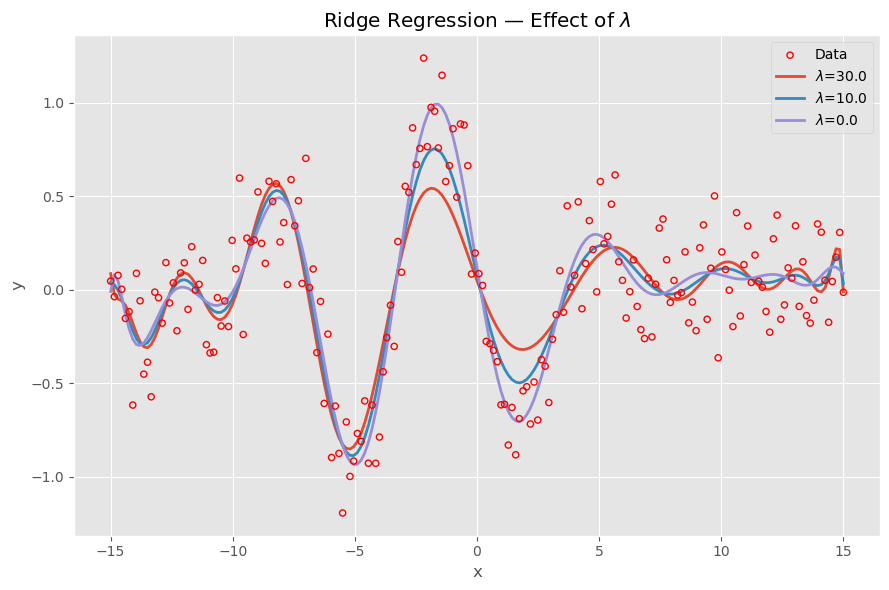

In [18]:
def fit_lr(X, y, la):
    """
    Ridge regression (L2 regularisation).

    Parameters
    ----------
    X  : design matrix
    y  : target vector
    la : regularisation strength λ
    """
    return np.linalg.solve(X.T @ X + la * np.eye(X.shape[1]), X.T @ y)

la_lst = [30.0, 10.0, 0.0]
plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=20, facecolors='none', edgecolors='red', linewidths=1, label='Data', zorder=5)

for la in la_lst:
    X_full = design_matrix(xi, deg)
    c      = fit_lr(X_full, yi, la)
    plt.plot(x_plt, predict(design_matrix(x_plt, deg), c),
             linewidth=2, label=f'$\\lambda$={la}')

plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title('Ridge Regression — Effect of $\\lambda$')
plt.tight_layout(); plt.show()


**Observation:**
- $\lambda = 0$ → no regularisation, model fits tightly but may overfit
- $\lambda = 30$ → model is too smooth, **underfits** (high bias)


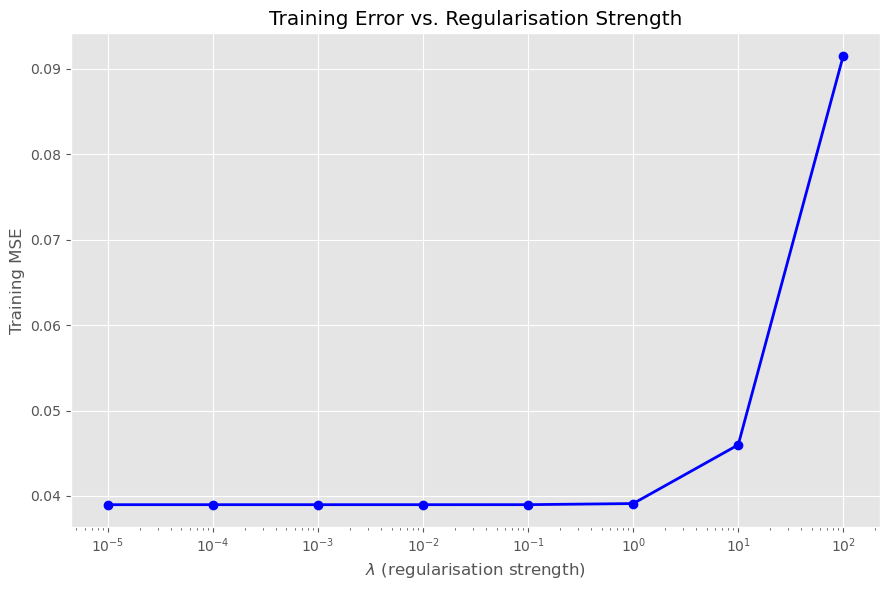

In [21]:
la_lst_log = np.logspace(-5, 2, 8)
mse_train_lst_lr = []
X_full = design_matrix(xi, deg)
for la in la_lst_log:
    c = fit_lr(X_full, yi, la)
    mse_train_lst_lr.append(mse(yi, predict(X_full, c)))

plt.figure(figsize=(9, 6))
plt.semilogx(la_lst_log, mse_train_lst_lr, 'bo-', linewidth=2)
plt.xlabel('$\\lambda$ (regularisation strength)'); plt.ylabel('Training MSE')
plt.title('Training Error vs. Regularisation Strength')
plt.tight_layout(); plt.show()


**Observation:** For $\lambda < 1$ the training error is low and stable.
For $\lambda > 1$ the regularisation dominates and training error rises.


## 8. Question 6 — Gaussian Basis Functions

$$\phi_k(x) = \exp\!\left\{-\frac{(x - \mu_k)^2}{2\sigma^2}\right\}$$

Each basis function is a Gaussian bump centred at $\mu_k$ with width $\sigma$.


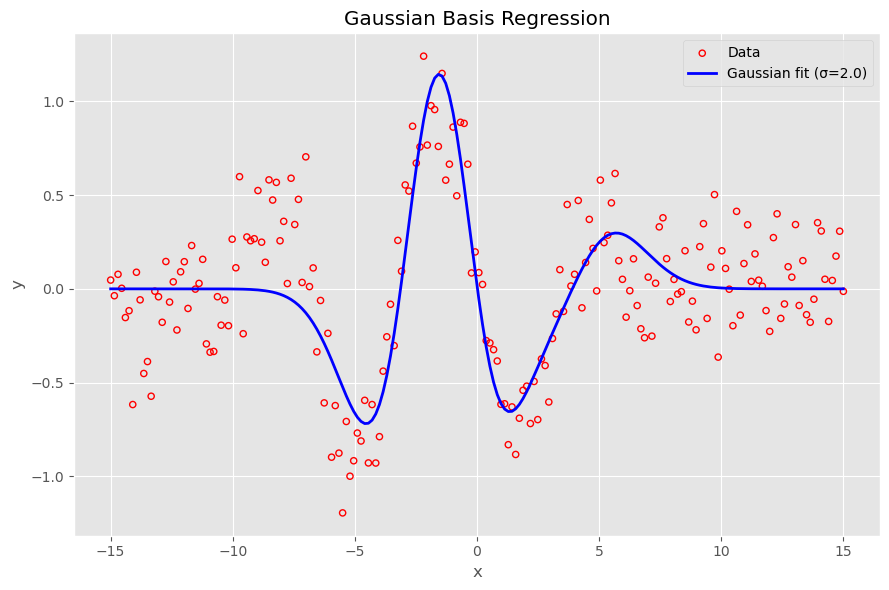

In [23]:
mu  = np.array([0.96682181, 0.11339223, 0.34433317, 0.16548527, 0.40411627,
                 0.68989358, 0.10684011, 0.20338468, 0.66804714, 0.05204953])
sig = 2.0

def design_matrix_gaussian(x, mu, sig):
    """Gaussian basis design matrix. Shape: (m, K)"""
    return np.exp(-0.5 * ((x[:, np.newaxis] - mu) / sig) ** 2)

X_gaussian = design_matrix_gaussian(xi, mu, sig)
coefs1      = fit(X_gaussian, yi)

X_plt_g      = design_matrix_gaussian(x_plt, mu, sig)
gaussian_model = predict(X_plt_g, coefs1)

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=20, facecolors='none', edgecolors='red', linewidths=1, label='Data')
plt.plot(x_plt, gaussian_model, 'b-', linewidth=2, label=f'Gaussian fit (σ={sig})')
plt.title('Gaussian Basis Regression'); plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.tight_layout(); plt.show()


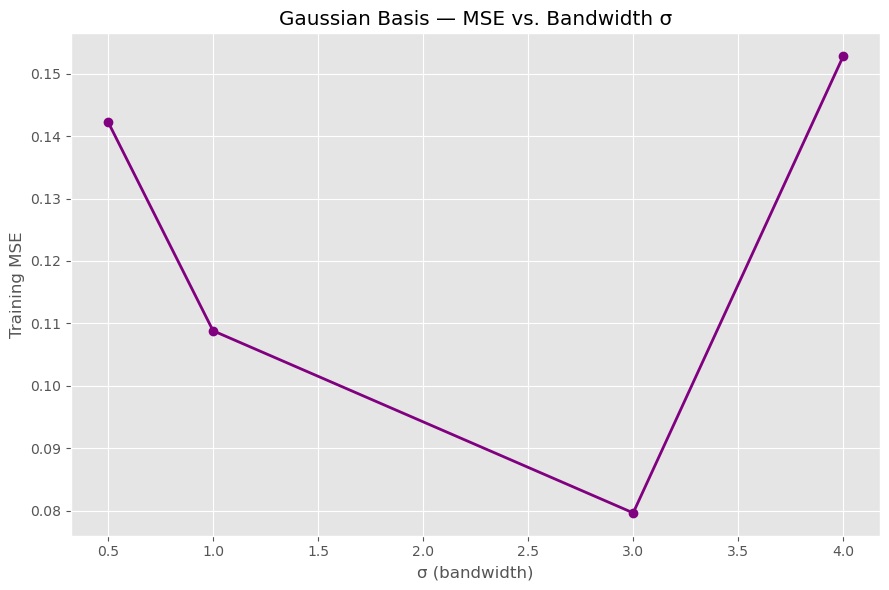

In [25]:
sig_lst      = [4, 3, 1, 0.5]
gaussian_mse = []

for sig_val in sig_lst:
    X_g_sig = design_matrix_gaussian(xi, mu, sig_val)
    c       = fit(X_g_sig, yi)
    gaussian_mse.append(mse(yi, predict(X_g_sig, c)))

plt.figure(figsize=(9, 6))
plt.plot(sig_lst, gaussian_mse, 'o-', color='purple', linewidth=2)
plt.xlabel('σ (bandwidth)'); plt.ylabel('Training MSE')
plt.title('Gaussian Basis — MSE vs. Bandwidth σ')
plt.tight_layout(); plt.show()


**Observation:**
- Large $\sigma$ → broad bumps → smooth global fit → may underfit
- Small $\sigma$ → narrow bumps → localised, noisy fit
- Optimal $\sigma \approx 3$ gives the best balance


## 9. Question 7 — Radial Basis Functions (RBF)

$$\hat{f}(x; \theta) = \sum_{i=1}^{m}\theta_i\,\phi(\|x - x_i\|), \qquad \phi(r) = e^{-(sr)^2}$$

The design matrix is **square** $(m \times m)$ — each training point is a centre.


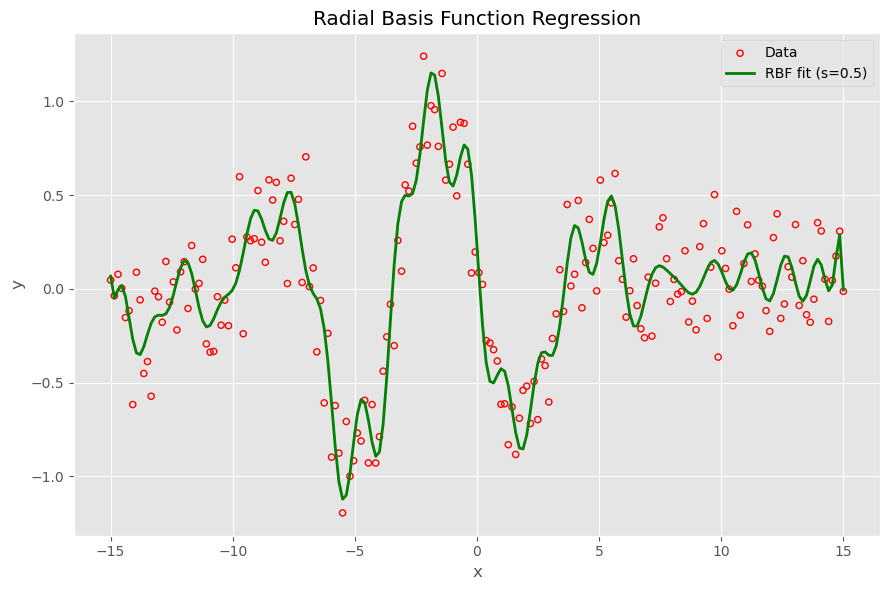

RBF Training MSE: 0.0431


In [27]:
s = 0.5

def design_matrix_radial(x, s):
    """RBF design matrix using training points as centres. Shape: (m, m)"""
    return np.array([np.exp(-(s * (x - x[i])) ** 2) for i in range(len(x))])

X_radial    = design_matrix_radial(xi, s)
coefs2      = fit(X_radial, yi)
radial_model = predict(X_radial, coefs2)

plt.figure(figsize=(9, 6))
plt.scatter(xi, yi, s=20, facecolors='none', edgecolors='red', linewidths=1, label='Data')
plt.plot(xi, radial_model, 'g-', linewidth=2, label=f'RBF fit (s={s})')
plt.title('Radial Basis Function Regression'); plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.tight_layout(); plt.show()
print(f'RBF Training MSE: {mse(yi, radial_model):.4f}')


**Observation:** The RBF model fits the data very well because it uses every training point as a centre. The trade-off is that the design matrix is $O(m^2)$ and the model may overfit on small datasets.


## 10. Logistic Regression with Gradient Descent

$$P(y=1|x) = \sigma(\theta^T x) = \frac{1}{1+e^{-\theta^T x}}$$

$$J(\theta) = -\frac{1}{m}\sum_i\left[y_i\log\sigma(\theta^T x_i) + (1-y_i)\log(1-\sigma(\theta^T x_i))\right]$$

> ⚠️ **Bug fixed:** The original sigmoid was `1/(1 - exp(-z))` which is mathematically wrong. The correct formula is `1/(1 + exp(-z))`. We also add `np.clip` to prevent overflow.
>
> ⚠️ **Bug fixed:** The original `grad(z)` function was an incorrect derivative. Below we use the standard logistic gradient $\nabla J = X^T(\hat{y} - y)/m$.
>
> ⚠️ **Bug fixed:** The original `gradientDescent` had `theta = #[YOUR CODE HERE]` — the update step was missing. It is now completed, and `computeCost` is defined in this notebook (no external dependency).


In [28]:
def sigmoid(z):
    """
    Sigmoid function: σ(z) = 1 / (1 + e^{-z})

    FIX: original code had 1/(1 - exp(-z)) which is wrong.
    We also clip z to avoid overflow in exp.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    """
    Derivative of sigmoid: σ'(z) = σ(z) * (1 - σ(z))

    FIX: original grad(z) formula was completely wrong.
    """
    s = sigmoid(z)
    return s * (1.0 - s)

# Quick sanity check
print('sigmoid(0)   =', sigmoid(0),   '  (expected 0.5)')
print('sigmoid(100) =', sigmoid(100), '  (expected ≈1.0)')
print('sigmoid(-100)=', sigmoid(-100),'  (expected ≈0.0)')


sigmoid(0)   = 0.5   (expected 0.5)
sigmoid(100) = 1.0   (expected ≈1.0)
sigmoid(-100)= 3.7200759760208356e-44   (expected ≈0.0)


In [29]:
def computeCost_logistic(X, y, theta):
    """
    Binary cross-entropy cost and gradient for logistic regression.

    FIX: defined here so the notebook is self-contained.

    Parameters
    ----------
    X     : design matrix  (m × n)
    y     : binary labels  (m,)  — values in {0, 1}
    theta : parameter vector (n,)

    Returns
    -------
    [cost, grad]
    """
    m    = len(y)
    h    = sigmoid(X.dot(theta))           # predictions
    eps  = 1e-15                            # avoid log(0)
    cost = -np.mean(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
    grad = X.T.dot(h - y) / m
    return [cost, grad]

def gradientDescent(X, y, theta, eta, num_iters):
    """
    Gradient descent for logistic regression.

    FIX: the update step `theta = #[YOUR CODE HERE]` is now completed.
    FIX: calls computeCost_logistic (defined above) — no external dependency.

    Parameters
    ----------
    X         : design matrix
    y         : binary labels
    theta     : initial parameter vector
    eta       : learning rate
    num_iters : number of iterations

    Returns
    -------
    [theta, lossVals, thetaVals]
    """
    lossVals  = []
    thetaVals = []
    for i in range(num_iters):
        thetaVals.append(theta.copy())
        loss, grad = computeCost_logistic(X, y, theta)
        theta = theta - eta * grad          # FIX: gradient descent update
        lossVals.append(loss)
    return [theta, lossVals, thetaVals]


### Apply Logistic Regression to `gabor_data.out`

We binarise the output $y$ using the median as threshold to create a classification problem.


Optimal theta: [1.37667655e-17 2.00310332e-02]
Final loss   : 0.6893735255831208
Training accuracy: 47.0%


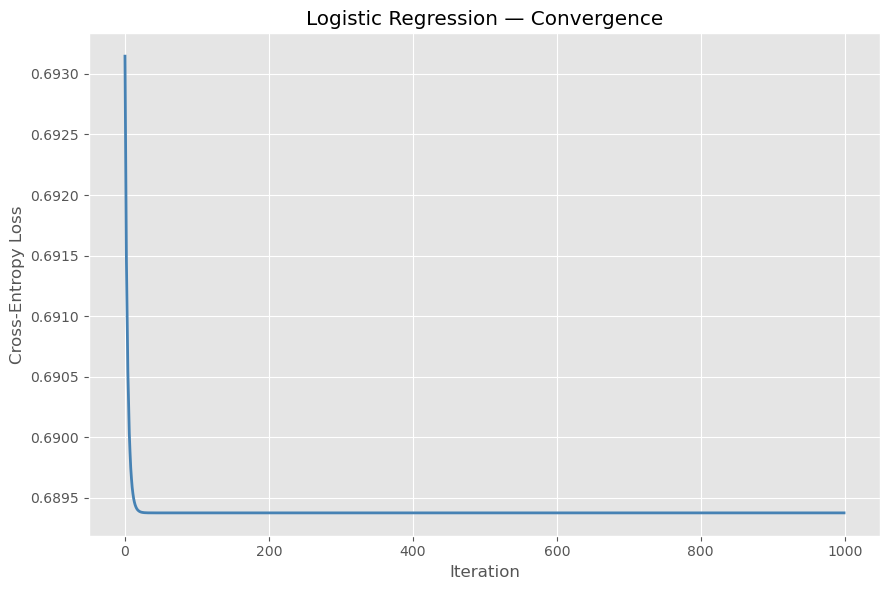

In [31]:
# Binarise yi using median threshold to create a classification problem
yi_binary = (yi >= np.median(yi)).astype(float)

# Design matrix with intercept
X_log = np.c_[np.ones(len(xi)), xi]

# Initial theta
theta_init = np.zeros(X_log.shape[1])

# Run gradient descent
eta_log   = 0.1
n_iters   = 1000
opt_theta, loss_history, _ = gradientDescent(X_log, yi_binary, theta_init, eta_log, n_iters)

print('Optimal theta:', opt_theta)
print('Final loss   :', loss_history[-1])

# Training accuracy
preds_binary = (sigmoid(X_log.dot(opt_theta)) >= 0.5).astype(float)
acc = np.mean(preds_binary == yi_binary)
print(f'Training accuracy: {acc*100:.1f}%')

# Plot convergence
plt.figure(figsize=(9, 6))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('Cross-Entropy Loss')
plt.title('Logistic Regression — Convergence')
plt.tight_layout(); plt.show()


## Summary

| Model | Basis | Normal Equation |
|---|---|---|
| Polynomial | $\{1, x, x^2, \ldots, x^d\}$ | $(\Phi^T\Phi)^{-1}\Phi^T y$ |
| Ridge | Polynomial + $\lambda I$ penalty | $(\Phi^T\Phi + \lambda I)^{-1}\Phi^T y$ |
| Gaussian | $e^{-(x-\mu_k)^2/2\sigma^2}$ | Same formula |
| RBF | $e^{-(s\|x-x_i\|)^2}$ | Same formula, $(m\times m)$ matrix |

**Key takeaway:** Model selection must be guided by **validation error**, not training error alone. Regularisation controls complexity without reducing model capacity.
